In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
np.random.seed(42)

n_customers = 500

customer_data = pd.DataFrame({
    "Customer_ID": [f"CUST_{i:04d}" for i in range(1, n_customers + 1)],
    "Age": np.random.randint(18, 61, n_customers),
    "Tenure_Months": np.random.randint(1, 61, n_customers),
    "Monthly_Spend": np.random.uniform(500, 10000, n_customers).round(2),
    "Purchase_Frequency": np.random.randint(1, 21, n_customers),
    "Engagement_Score": np.random.uniform(10, 100, n_customers).round(2),
    "Service_Inquiries": np.random.randint(0, 11, n_customers),
    "Learning_Interest": np.random.uniform(10, 100, n_customers).round(2),
    "Avg_Session_Minutes": np.random.uniform(5, 180, n_customers).round(2)
})

customer_data.head()

,Customer_ID,Age,Tenure_Months,Monthly_Spend,Purchase_Frequency,Engagement_Score,Service_Inquiries,Learning_Interest,Avg_Session_Minutes
0,CUST_0001,56,18,6271.77,19,20.11,5,96.76,121.03
1,CUST_0002,46,49,2821.35,10,10.23,1,44.58,134.83
2,CUST_0003,32,39,5233.35,10,67.42,0,13.51,153.47
3,CUST_0004,60,32,3638.31,11,56.37,9,12.79,78.96
4,CUST_0005,25,24,9370.07,7,63.42,4,44.92,58.01


In [3]:
customer_data.to_csv("customer_data.csv", index=False)

print("Dataset created successfully.")
print("Shape:", customer_data.shape)

Dataset created successfully.
Shape: (500, 9)


In [4]:
df = pd.read_csv("customer_data.csv")

print("Dataset Shape:", df.shape)
print("\nDataset Information:")
df.info()

Dataset Shape: (500, 9)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          500 non-null    object 
 1   Age                  500 non-null    int64  
 2   Tenure_Months        500 non-null    int64  
 3   Monthly_Spend        500 non-null    float64
 4   Purchase_Frequency   500 non-null    int64  
 5   Engagement_Score     500 non-null    float64
 6   Service_Inquiries    500 non-null    int64  
 7   Learning_Interest    500 non-null    float64
 8   Avg_Session_Minutes  500 non-null    float64
dtypes: float64(4), int64(4), object(1)
memory usage: 35.3+ KB


In [5]:
df.describe()

,Age,Tenure_Months,Monthly_Spend,Purchase_Frequency,Engagement_Score,Service_Inquiries,Learning_Interest,Avg_Session_Minutes
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000
mean,39.506000,30.766000,5430.687000,10.574000,53.690020,4.86600,54.763080,92.412000
std,12.368505,17.360935,2739.110308,5.720662,25.685443,3.12403,26.664877,49.736648
min,18.000000,1.000000,502.260000,1.000000,10.030000,0.00000,10.000000,5.350000
25%,29.000000,16.000000,3091.550000,6.000000,30.690000,2.00000,32.507500,49.195000
50%,41.000000,30.000000,5535.500000,11.000000,53.765000,5.00000,53.730000,94.490000
75%,50.000000,47.000000,7776.637500,15.000000,76.072500,7.25000,78.912500,133.950000
max,60.000000,60.000000,9993.860000,20.000000,99.590000,10.00000,99.800000,179.810000


In [6]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Tenure_Months,0
Monthly_Spend,0
Purchase_Frequency,0
Engagement_Score,0
Service_Inquiries,0
Learning_Interest,0
Avg_Session_Minutes,0


<Figure size 1200x800 with 0 Axes>

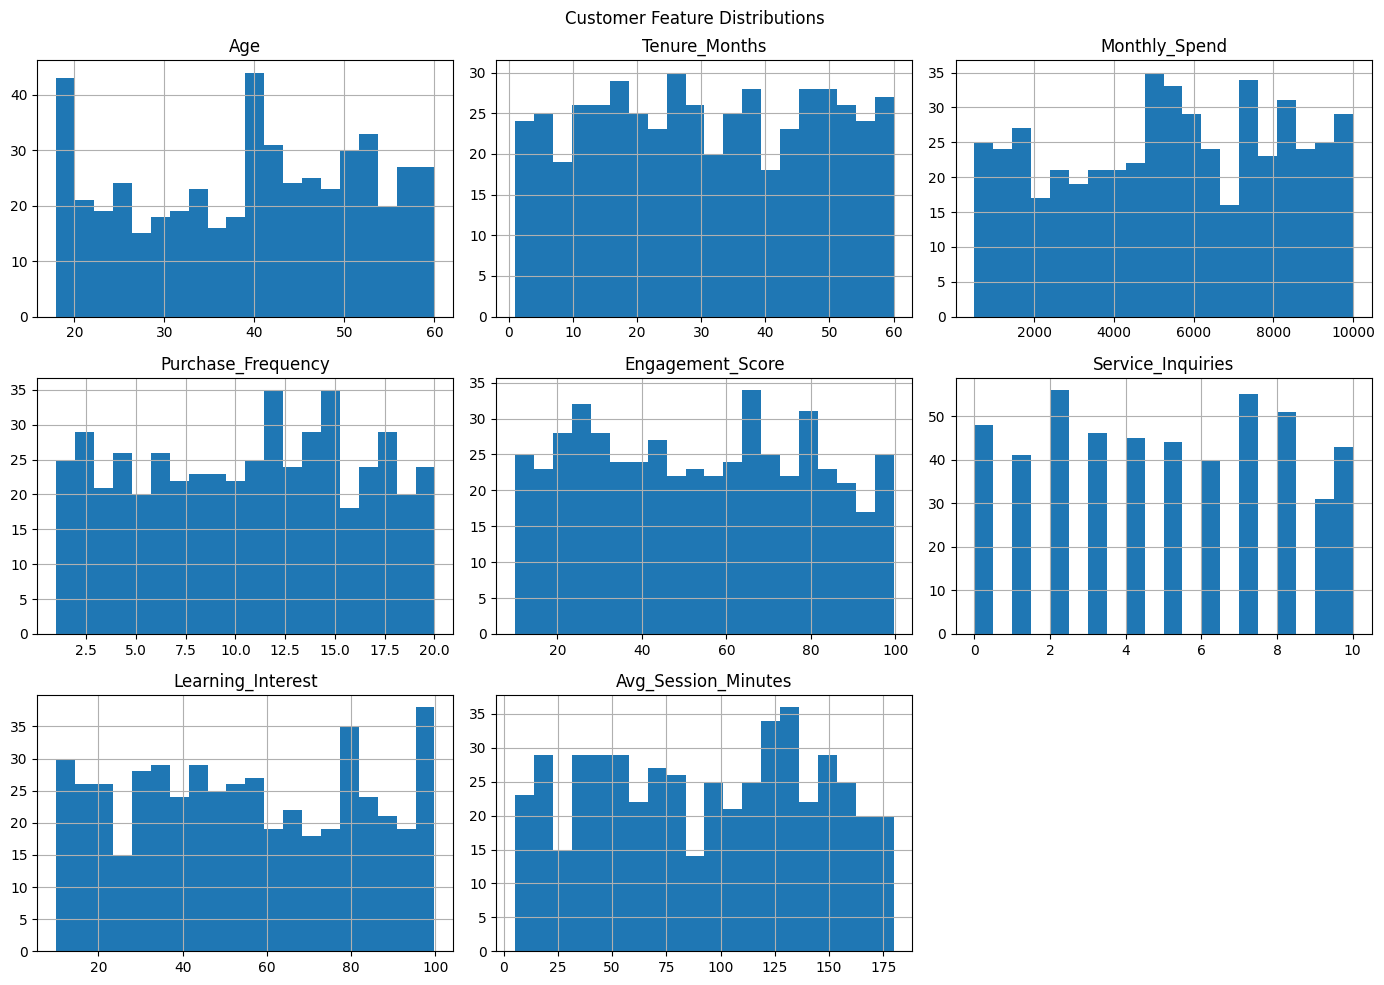

In [7]:
numeric_features = [
    "Age",
    "Tenure_Months",
    "Monthly_Spend",
    "Purchase_Frequency",
    "Engagement_Score",
    "Service_Inquiries",
    "Learning_Interest",
    "Avg_Session_Minutes"
]

plt.figure(figsize=(12, 8))

df[numeric_features].hist(
    figsize=(14, 10),
    bins=20
)

plt.suptitle("Customer Feature Distributions")
plt.tight_layout()
plt.show()

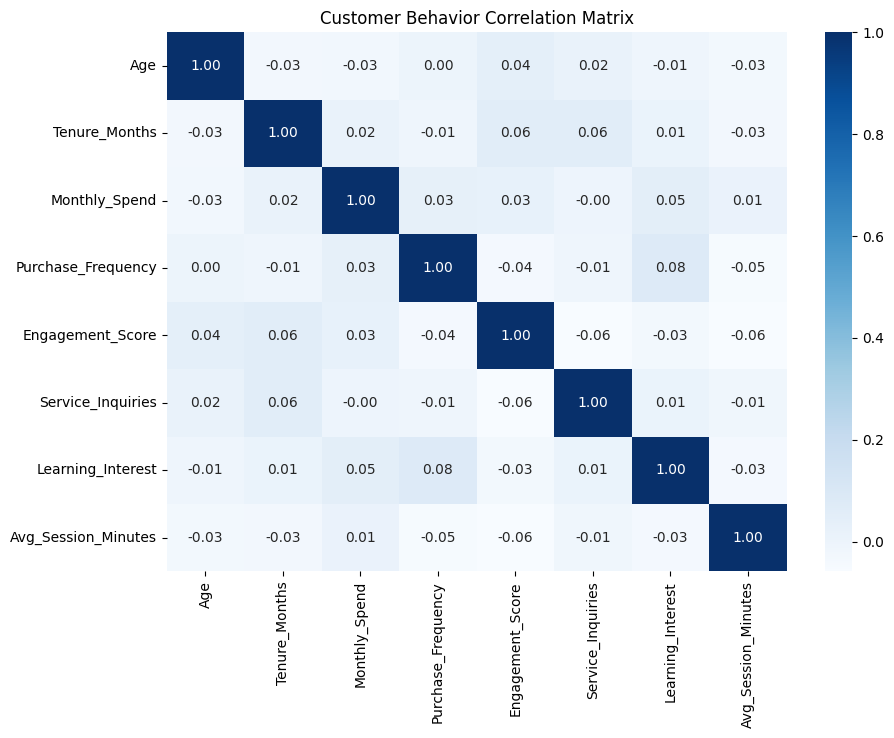

In [8]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[numeric_features].corr(),
    annot=True,
    cmap="Blues",
    fmt=".2f"
)

plt.title("Customer Behavior Correlation Matrix")
plt.show()

In [9]:
df["Spend_per_Purchase"] = (
    df["Monthly_Spend"] /
    df["Purchase_Frequency"].replace(0, 1)
)

df["Engagement_per_Session"] = (
    df["Engagement_Score"] /
    df["Avg_Session_Minutes"].replace(0, 1)
)

df["Customer_Value_Score"] = (
    0.4 * df["Monthly_Spend"] / df["Monthly_Spend"].max()
    + 0.3 * df["Purchase_Frequency"] / df["Purchase_Frequency"].max()
    + 0.3 * df["Engagement_Score"] / df["Engagement_Score"].max()
) * 100

df.head()

,Customer_ID,Age,Tenure_Months,Monthly_Spend,Purchase_Frequency,Engagement_Score,Service_Inquiries,Learning_Interest,Avg_Session_Minutes,Spend_per_Purchase,Engagement_per_Session,Customer_Value_Score
0,CUST_0001,56,18,6271.77,19,20.11,5,96.76,121.03,330.093158,0.166157,59.660330
1,CUST_0002,46,49,2821.35,10,10.23,1,44.58,134.83,282.135000,0.075873,29.373968
2,CUST_0003,32,39,5233.35,10,67.42,0,13.51,153.47,523.335000,0.439304,56.255529
3,CUST_0004,60,32,3638.31,11,56.37,9,12.79,78.96,330.755455,0.713906,48.042802
4,CUST_0005,25,24,9370.07,7,63.42,4,44.92,58.01,1338.581429,1.093260,67.107635


In [10]:
clustering_features = [
    "Age",
    "Tenure_Months",
    "Monthly_Spend",
    "Purchase_Frequency",
    "Engagement_Score",
    "Service_Inquiries",
    "Learning_Interest",
    "Avg_Session_Minutes",
    "Spend_per_Purchase",
    "Customer_Value_Score"
]

X = df[clustering_features]

print("Features used for clustering:")
print(clustering_features)

Features used for clustering:
['Age', 'Tenure_Months', 'Monthly_Spend', 'Purchase_Frequency', 'Engagement_Score', 'Service_Inquiries', 'Learning_Interest', 'Avg_Session_Minutes', 'Spend_per_Purchase', 'Customer_Value_Score']


In [11]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Feature scaling completed.")
print("Scaled data shape:", X_scaled.shape)

Feature scaling completed.
Scaled data shape: (500, 10)


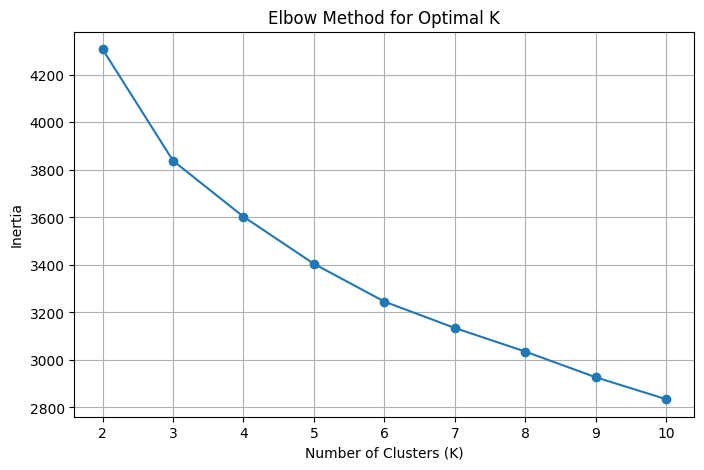

In [12]:
inertia = []

K_range = range(2, 11)

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(K_range, inertia, marker="o")

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.grid(True)
plt.show()

In [13]:
plt.savefig("elbow_curve.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

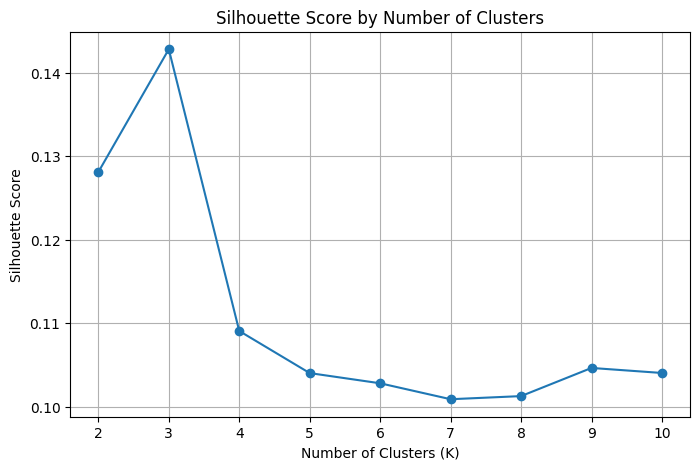

In [14]:
silhouette_scores = []

for k in K_range:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))

plt.plot(
    K_range,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")

plt.grid(True)
plt.show()

In [15]:
best_k = K_range[np.argmax(silhouette_scores)]

print("Best K based on silhouette score:", best_k)
print(
    "Best silhouette score:",
    round(max(silhouette_scores), 4)
)

Best K based on silhouette score: 3
Best silhouette score: 0.1428


In [16]:
kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("K-Means clustering completed.")
print(df["Cluster"].value_counts().sort_index())

K-Means clustering completed.
Cluster
0    217
1    227
2     56
Name: count, dtype: int64


In [17]:
cluster_profile = df.groupby("Cluster")[clustering_features].mean()

cluster_profile.round(2)

,Age,Tenure_Months,Monthly_Spend,Purchase_Frequency,Engagement_Score,Service_Inquiries,Learning_Interest,Avg_Session_Minutes,Spend_per_Purchase,Customer_Value_Score
Cluster,,,,,,,,,,
0,39.63,28.99,3206.97,9.40,44.40,4.88,51.80,94.05,534.83,40.31
1,39.20,31.86,7116.12,13.74,61.62,4.73,56.85,87.88,602.80,67.65
2,40.27,33.23,7215.57,2.30,57.53,5.34,57.76,104.46,3817.26,49.67


In [18]:
segment_names = {
    0: "Premium Engaged Customers",
    1: "Occasional Users",
    2: "Learning-Focused Customers",
    3: "Service-Support Customers"
}

df["Segment"] = df["Cluster"].map(segment_names)

df[["Customer_ID", "Cluster", "Segment"]].head()

,Customer_ID,Cluster,Segment
0,CUST_0001,1,Occasional Users
1,CUST_0002,0,Premium Engaged Customers
2,CUST_0003,1,Occasional Users
3,CUST_0004,0,Premium Engaged Customers
4,CUST_0005,1,Occasional Users


In [19]:
def recommend_service(row):

    if row["Learning_Interest"] >= 70:
        return "Advanced Data Science / AI Learning Program"

    elif row["Monthly_Spend"] >= 7000 and row["Engagement_Score"] >= 70:
        return "Premium Membership & Advanced Services"

    elif row["Service_Inquiries"] >= 7:
        return "Priority Customer Support Program"

    elif row["Engagement_Score"] < 40:
        return "Engagement Booster Program"

    else:
        return "Starter Learning & Service Package"


df["Recommended_Service"] = df.apply(
    recommend_service,
    axis=1
)

df[
    [
        "Customer_ID",
        "Segment",
        "Recommended_Service"
    ]
].head(10)

,Customer_ID,Segment,Recommended_Service
0,CUST_0001,Occasional Users,Advanced Data Science / AI Learning Program
1,CUST_0002,Premium Engaged Customers,Engagement Booster Program
2,CUST_0003,Occasional Users,Starter Learning & Service Package
3,CUST_0004,Premium Engaged Customers,Priority Customer Support Program
4,CUST_0005,Occasional Users,Starter Learning & Service Package
5,CUST_0006,Premium Engaged Customers,Starter Learning & Service Package
6,CUST_0007,Premium Engaged Customers,Starter Learning & Service Package
7,CUST_0008,Premium Engaged Customers,Advanced Data Science / AI Learning Program
8,CUST_0009,Premium Engaged Customers,Priority Customer Support Program
9,CUST_0010,Occasional Users,Premium Membership & Advanced Services


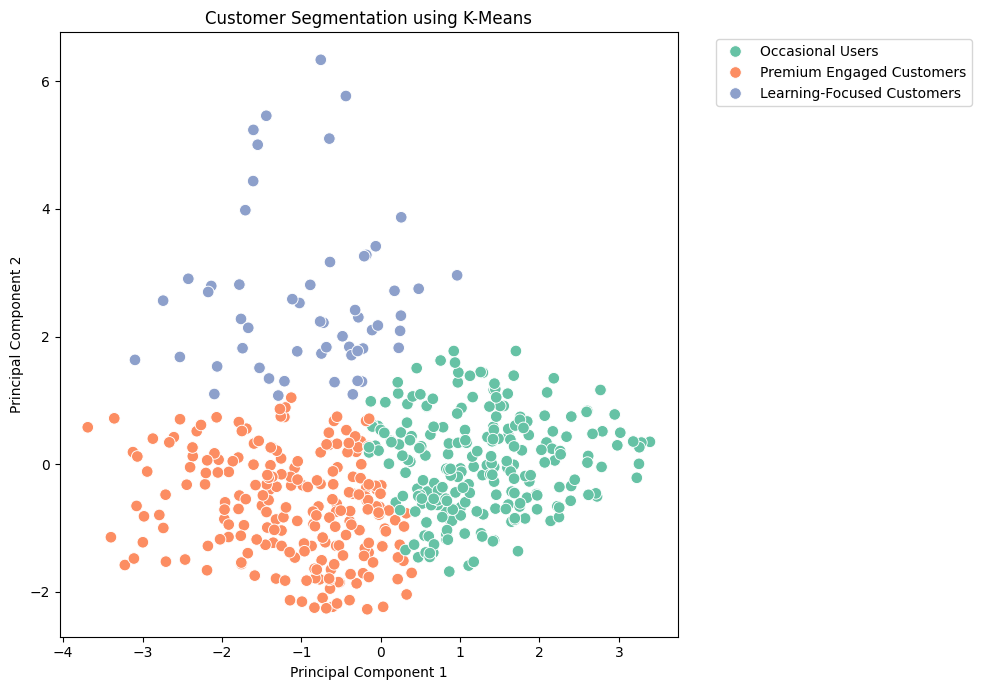

In [20]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=df,
    x="PCA1",
    y="PCA2",
    hue="Segment",
    palette="Set2",
    s=70
)

plt.title("Customer Segmentation using K-Means")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [21]:
plt.savefig(
    "cluster_visualization.png",
    dpi=300,
    bbox_inches="tight"
)

<Figure size 640x480 with 0 Axes>

In [22]:
print("CUSTOMER SEGMENTATION BUSINESS INSIGHTS")
print("=" * 50)

for cluster in sorted(df["Cluster"].unique()):

    segment = df[df["Cluster"] == cluster]

    print(f"\nSegment: {segment['Segment'].iloc[0]}")
    print(f"Customers: {len(segment)}")
    print(
        f"Average Spend: ₹{segment['Monthly_Spend'].mean():.2f}"
    )
    print(
        f"Average Engagement: "
        f"{segment['Engagement_Score'].mean():.2f}"
    )
    print(
        f"Average Learning Interest: "
        f"{segment['Learning_Interest'].mean():.2f}"
    )

CUSTOMER SEGMENTATION BUSINESS INSIGHTS

Segment: Premium Engaged Customers
Customers: 217
Average Spend: ₹3206.97
Average Engagement: 44.40
Average Learning Interest: 51.80

Segment: Occasional Users
Customers: 227
Average Spend: ₹7116.12
Average Engagement: 61.62
Average Learning Interest: 56.85

Segment: Learning-Focused Customers
Customers: 56
Average Spend: ₹7215.57
Average Engagement: 57.53
Average Learning Interest: 57.76


In [23]:
df.to_csv(
    "customer_segmented_data.csv",
    index=False
)

print("Final segmented dataset saved successfully.")

Final segmented dataset saved successfully.
